Accuracy: 84.44444444444444


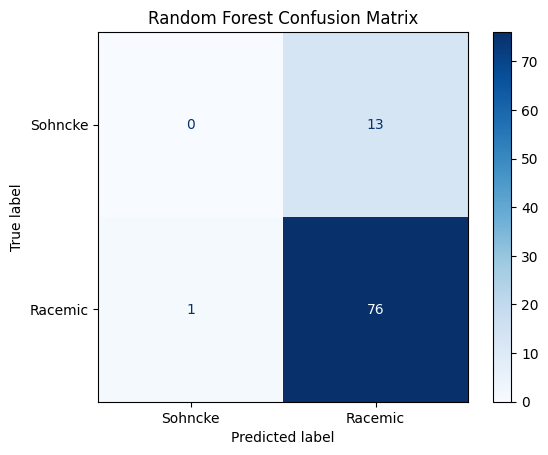

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn import metrics

df = pd.read_csv(r'filtered and normalised all descriptor data.csv')
df = df.drop(columns=['Refcode', 'Point group'])

X = df.drop(columns='Target') # Creating a new dataframe without the sohncke/racemic answers
y = df['Target'] # Creating a new dataframe with just the sohncke/racemic answers

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3) # Generating the training and testing data with a 70/30 split

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:",metrics.accuracy_score(y_test, y_pred)*100) # Printing out the accuracy

# Outputting the confusion matrix
ConfusionMatrixDisplay.from_estimator(
    rf, 
    X_test, 
    y_test, 
    display_labels=["Sohncke", "Racemic"],
    cmap=plt.cm.Blues,
    values_format='d'
);
plt.title('Random Forest Confusion Matrix');

